<a href="https://colab.research.google.com/github/faishal-ai/PCVK/blob/main/WEEK_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow

In [2]:
from google.colab import drive

#Accessing My google drive
drive.mount('/content/drive')

Mounted at /content/drive


 Mengubah tingkat kecerahan citra 
------------------------------------
Masukkan nilai kecerahan: 50


/tmp/ipython-input-1781300739.py:15: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


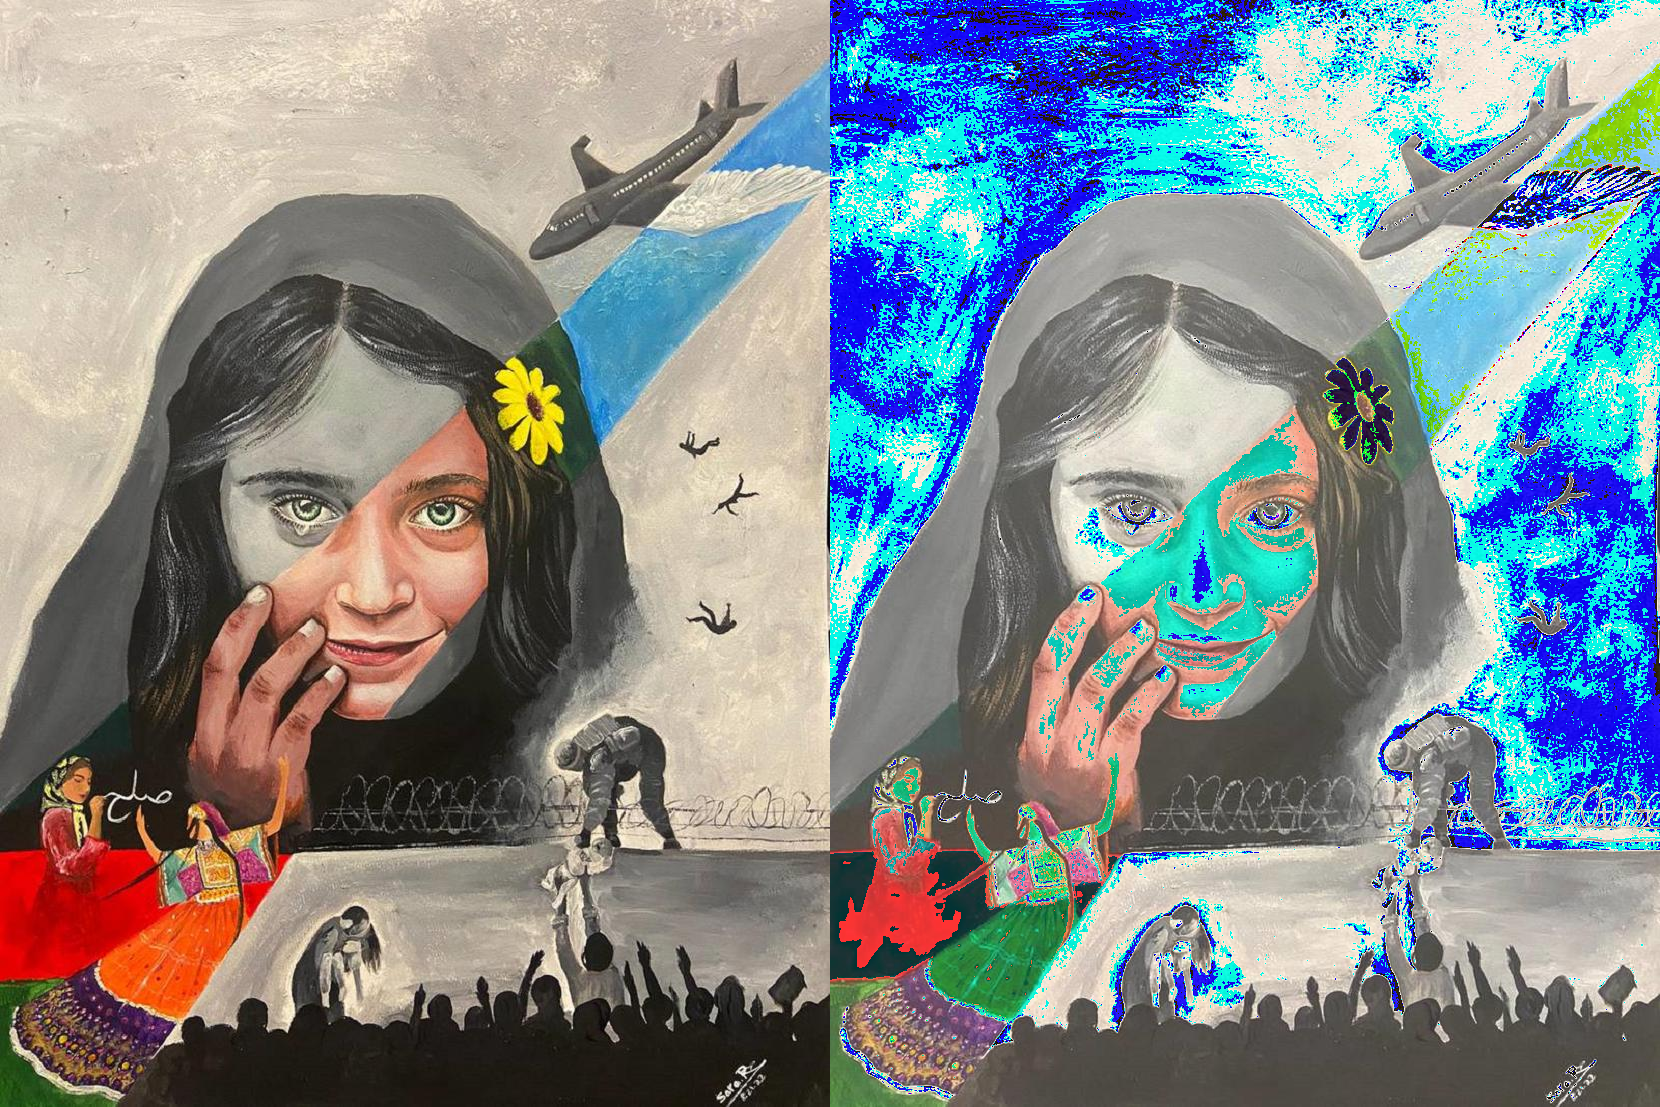

In [3]:
print(' Mengubah tingkat kecerahan citra ')
print('------------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/lukisan.png')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

TUGAS PRAKTIKUM D1

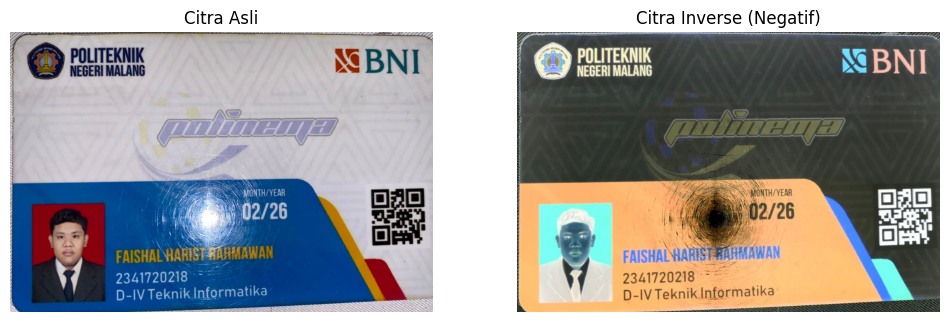

In [4]:
# soal 1

import cv2 as cv
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/ktm.jpg')

# Konversi BGR ke RGB agar warnanya sesuai saat ditampilkan di matplotlib
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Lakukan inverse citra (citra negatif)
inverse_img = 255 - img_rgb

# Tampilkan hasil
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Citra Asli")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Citra Inverse (Negatif)")
plt.imshow(inverse_img)
plt.axis("off")

plt.show()


/tmp/ipython-input-2496455663.py:24: RuntimeWarning: overflow encountered in scalar subtract
  new_val = factor * (image[y,x,c] - 128) + 128 + brightness


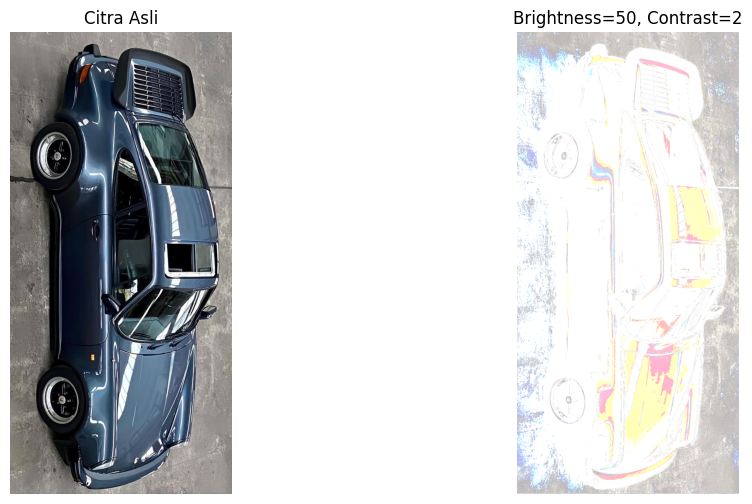

In [5]:
#soal 2

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/mobil.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Input brightness & contrast
brightness = 50   # range [-255, 255]
contrast = 2      # range [1.0, 3.0]

# Hitung Contrast Correction Factor
factor = (259 * (contrast + 255)) / (255 * (259 - contrast))

# Terapkan transformasi brightness + contrast
def apply_contrast_brightness(image, contrast_factor, brightness):
    new_img = np.zeros_like(image)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            for c in range(image.shape[2]):
                new_val = factor * (image[y,x,c] - 128) + 128 + brightness
                # Truncate agar tetap dalam 0–255
                new_img[y,x,c] = np.clip(new_val, 0, 255)
    return new_img.astype(np.uint8)

result = apply_contrast_brightness(img_rgb, factor, brightness)

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Citra Asli")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title(f"Brightness={brightness}, Contrast={contrast}")
plt.imshow(result)
plt.axis("off")

plt.show()


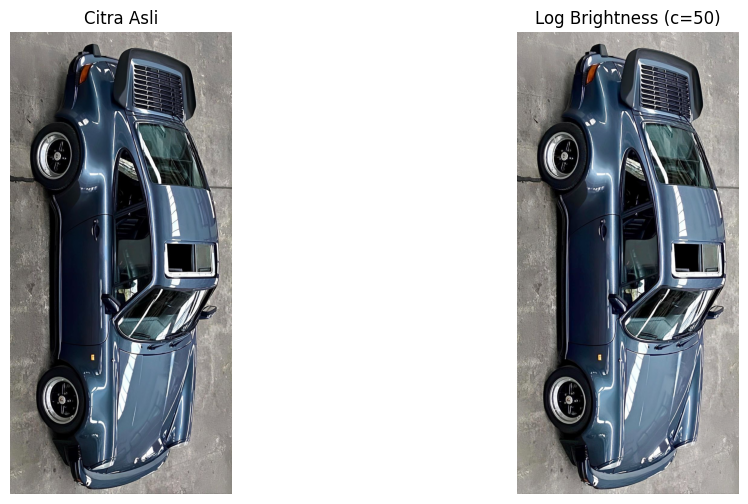

In [6]:
# soal 3

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/mobil.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Masukkan nilai brightness (c konstanta log)
brightness = 50

# Normalisasi pixel ke range [0,1]
img_normalized = img_rgb / 255.0

# Terapkan transformasi log
c = brightness / np.log(1 + np.max(img_normalized))  # konstanta
log_transformed = c * np.log(1 + img_normalized)

# Skala balik ke [0,255]
log_transformed = np.uint8(255 * log_transformed / np.max(log_transformed))

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Citra Asli")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title(f"Log Brightness (c={brightness})")
plt.imshow(log_transformed)
plt.axis("off")

plt.show()


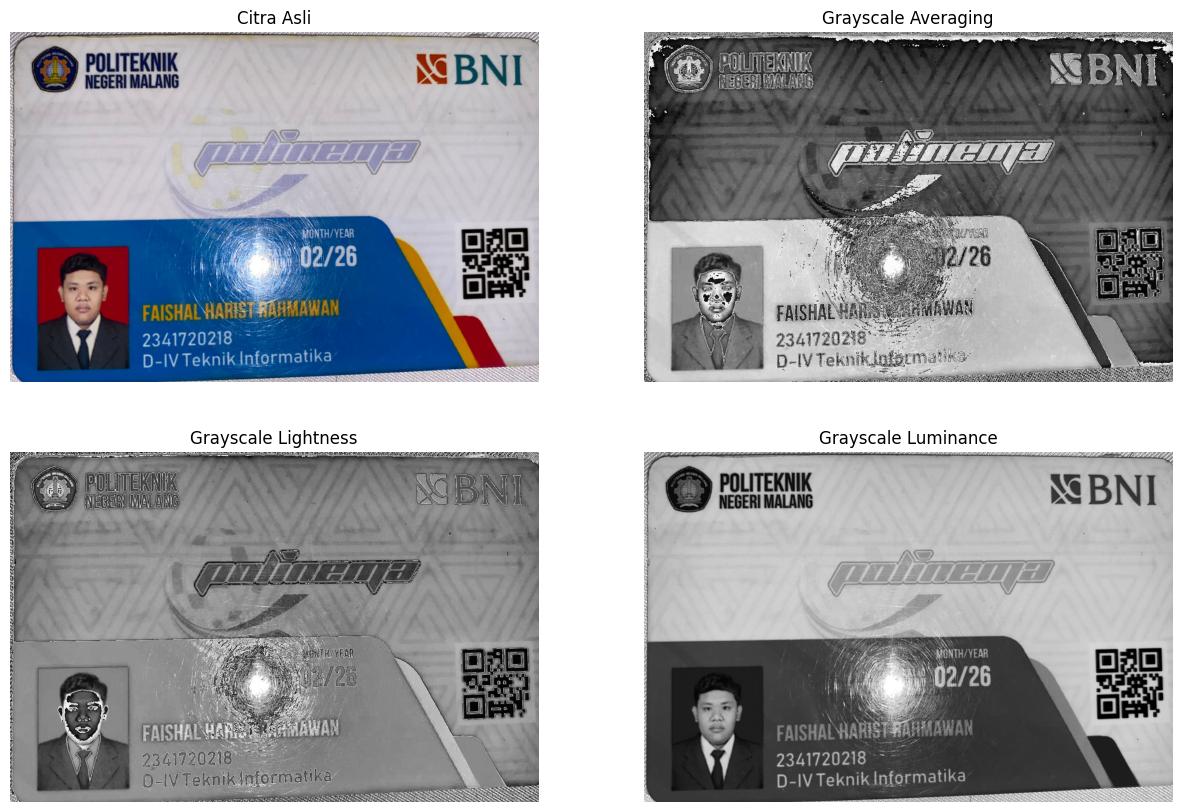

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/ktm.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Ekstrak channel
R = img_rgb[:,:,0]
G = img_rgb[:,:,1]
B = img_rgb[:,:,2]

# 1. Grayscale Averaging
gray_avg = ((R + G + B) / 3).astype(np.uint8)

# 2. Grayscale Lightness
gray_lightness = ((np.maximum.reduce([R,G,B]) + np.minimum.reduce([R,G,B])) / 2).astype(np.uint8)

# 3. Grayscale Luminance
gray_luminance = (0.21*R + 0.72*G + 0.07*B).astype(np.uint8)

# Tampilkan hasil
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.title("Citra Asli")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(2,2,2)
plt.title("Grayscale Averaging")
plt.imshow(gray_avg, cmap='gray')
plt.axis("off")

plt.subplot(2,2,3)
plt.title("Grayscale Lightness")
plt.imshow(gray_lightness, cmap='gray')
plt.axis("off")

plt.subplot(2,2,4)
plt.title("Grayscale Luminance")
plt.imshow(gray_luminance, cmap='gray')
plt.axis("off")

plt.show()


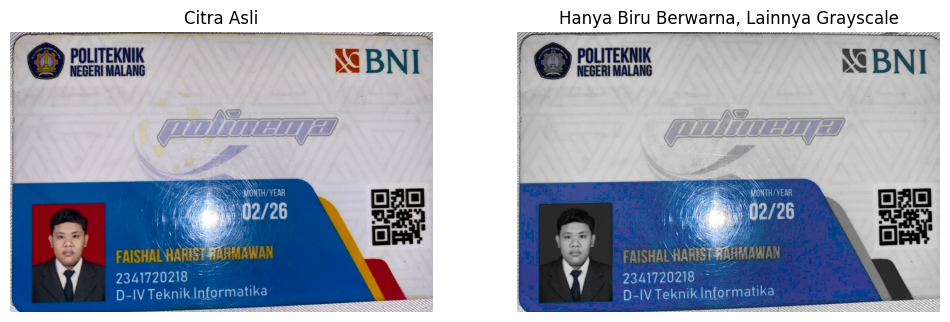

In [8]:
# saol 5
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/ktm.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Konversi ke HSV
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# Range warna biru (HSV)
lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])

# Buat mask untuk warna biru
mask = cv.inRange(hsv, lower_blue, upper_blue)

# Ambil bagian biru (warna asli)
blue_part = cv.bitwise_and(img_rgb, img_rgb, mask=mask)

# Konversi gambar asli ke grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_rgb = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

# Gabungkan: biru tetap berwarna, sisanya grayscale
final_result = np.where(blue_part != 0, img_rgb, gray_rgb)

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Citra Asli")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Hanya Biru Berwarna, Lainnya Grayscale")
plt.imshow(final_result)
plt.axis("off")

plt.show()

D2. Operasi Aritmatika dan Logika

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 12


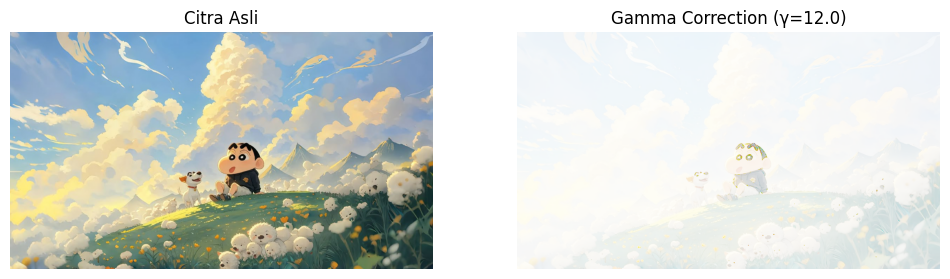

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print(' Gamma Correction pada citra ')
print('----------------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    gamma = 1.0

# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/sincan.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Normalisasi ke [0,1]
normalized = img_rgb / 255.0

# Terapkan Gamma Correction
gamma_corrected = np.power(normalized, 1.0/gamma)

# Skala balik ke [0,255]
gamma_corrected = np.uint8(gamma_corrected * 255)

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Citra Asli")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title(f"Gamma Correction (γ={gamma})")
plt.imshow(gamma_corrected)
plt.axis("off")

plt.show()


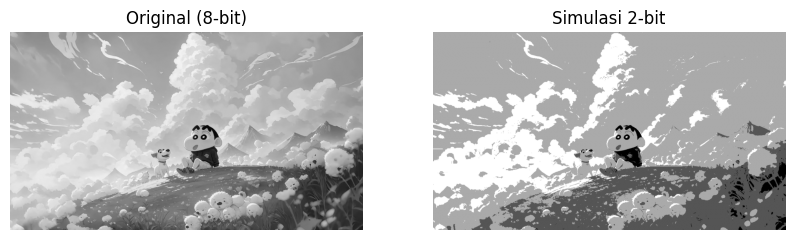

In [10]:
#soal 2

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Tentukan bit depth
bit_depth = 2
level = 255 / (pow(2, bit_depth) - 1)

# Baca gambar grayscale
original = cv.imread('/content/drive/MyDrive/PCVK/sincan.jpg', cv.IMREAD_GRAYSCALE)

# Buat array kosong untuk hasil
depth_image = np.zeros(original.shape, original.dtype)

# Lakukan kuantisasi
for i in range(original.shape[0]):
    for j in range(original.shape[1]):
        depth_image[i, j] = round(original[i, j] / level) * level

# Tampilkan hasil
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original, cmap='gray')
plt.title("Original (8-bit)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(depth_image, cmap='gray')
plt.title(f"Simulasi {bit_depth}-bit")
plt.axis("off")

plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


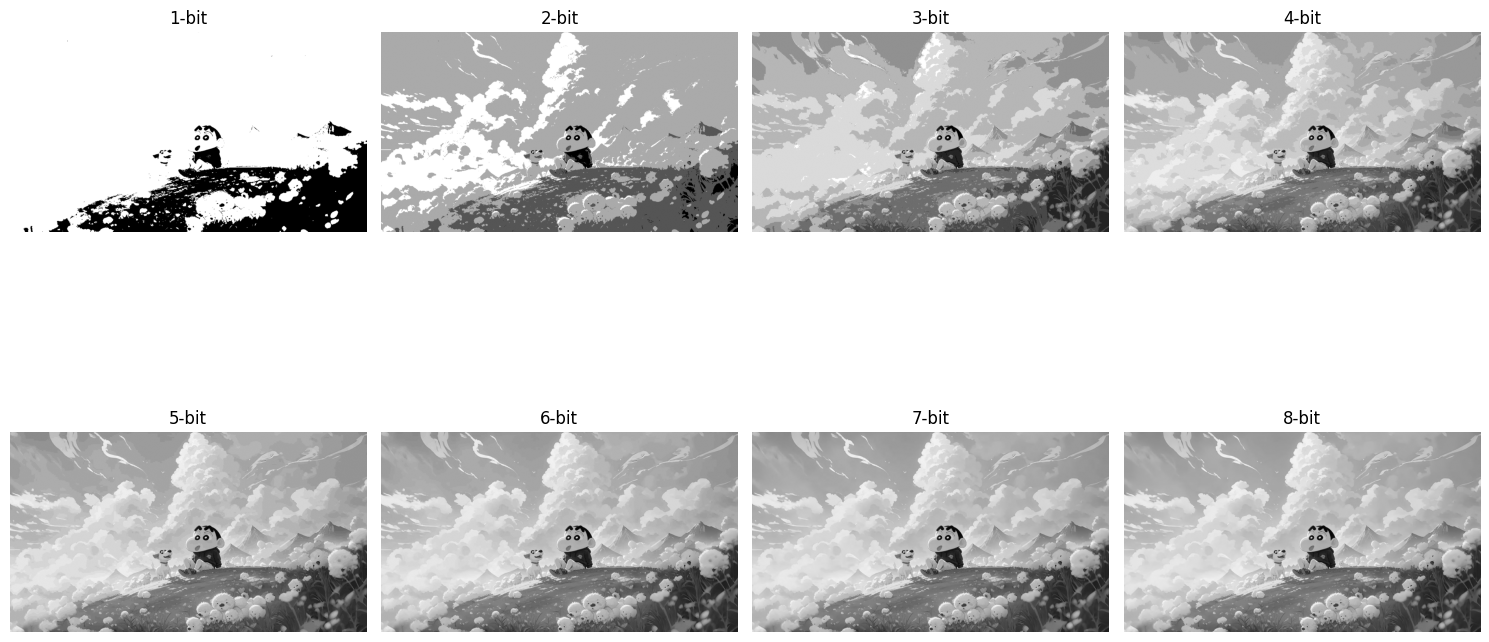

In [11]:
#soal no 3

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Path gambar (langsung ke file)
filename = "/content/drive/MyDrive/PCVK/sincan.jpg"

# Cek apakah file ada
if not os.path.exists(filename):
    raise FileNotFoundError("File tidak ditemukan, cek kembali path!")

# Baca gambar grayscale
original = cv.imread(filename, cv.IMREAD_GRAYSCALE)

# Fungsi untuk simulasi bit depth
def simulate_bit_depth(img, bit_depth):
    level = 255 / (pow(2, bit_depth) - 1)
    img_quantized = np.round(img / level) * level
    return img_quantized.astype(np.uint8)

# Uji coba dengan beberapa bit depth
bit_depths = [1, 2, 3, 4, 5, 6, 7, 8]

plt.figure(figsize=(15,10))
for i, depth in enumerate(bit_depths):
    quantized = simulate_bit_depth(original, depth)
    plt.subplot(2, 4, i+1)
    plt.imshow(quantized, cmap='gray')
    plt.title(f"{depth}-bit")
    plt.axis("off")

plt.tight_layout()
plt.show()


Buat Image Masking

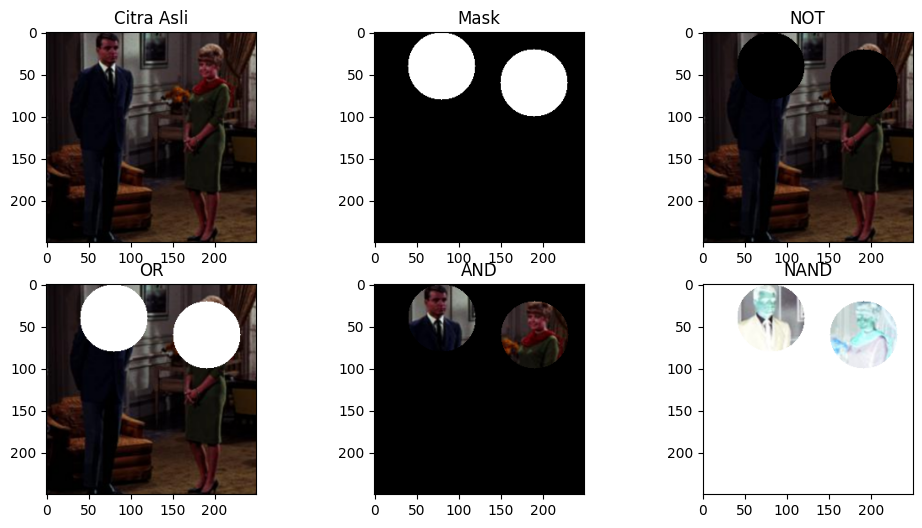

In [19]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

img = cv.imread('/content/drive/MyDrive/PCVK/berbi.png')
img = cv.resize(img, (250, 250))

mask = np.zeros((250, 250), dtype="uint8")
cv.circle(mask, (80, 40), 40, 255, -1)
cv.circle(mask, (190, 60), 40, 255, -1)

mask_3 = cv.merge([mask, mask, mask])

# 1. NOT (komplemen)
not_mask = cv.bitwise_not(mask_3)
not_result = cv.bitwise_and(img, not_mask)

# 2. OR
or_result = cv.bitwise_or(img, mask_3)

# 3. AND
and_result = cv.bitwise_and(img, mask_3)

# 4. NAND (Not AND)
nand_result = cv.bitwise_not(and_result)

titles = ['Citra Asli', 'Mask', 'NOT', 'OR', 'AND', 'NAND']
images = [img, mask_3, not_result, or_result, and_result, nand_result]

plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(cv.cvtColor(images[i], cv.COLOR_BGR2RGB))
    plt.title(titles[i])
plt.show()
